In [2]:
print("Set up complete and ready to go!")

Set up complete and ready to go!


In [3]:
import pandas as pd
import numpy as np  
import warnings
warnings.filterwarnings('ignore')   

In [4]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None) 

In [5]:
df =pd.read_csv('ESG_Data.csv',parse_dates=['Date'])

In [6]:
df.head()

,Date,Year,Asset_ID,Asset_Type,Location,Operational_Status,Energy_Type,Consumption_Units,Emission_Type,Emissions_tCO2e,Target_Emissions_tCO2e,Reduction_Percentage_vs_BaseYear
0,2020-01-01,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2357.044,Scope 1,0.645377,15004.345,0.0
1,2020-01-01,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2357.044,Scope 2,0.530871,15004.345,0.0
2,2020-01-02,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2440.574,Scope 1,0.688000,15004.345,0.0
3,2020-01-02,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2440.574,Scope 2,0.572372,15004.345,0.0
4,2020-01-03,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2396.825,Scope 1,0.715998,15004.345,0.0


DATA EXAMINATION


In [7]:
print(f"data shape: {df.shape}\n")
print(f"data columns: {df.columns}\n")
print(f"data info: {df.info()}\n")
print(f"data description: {df.describe()}\n")
print(f"data null values: {df.isnull().sum()}\n")
print(f"data duplicates: {df.duplicated().sum()}\n")
print(f"data date range: {df['Date'].min()} to {df['Date'].max()}")

data shape: (236736, 12)

data columns: Index(['Date', 'Year', 'Asset_ID', 'Asset_Type', 'Location',
       'Operational_Status', 'Energy_Type', 'Consumption_Units',
       'Emission_Type', 'Emissions_tCO2e', 'Target_Emissions_tCO2e',
       'Reduction_Percentage_vs_BaseYear'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 236736 entries, 0 to 236735
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   Date                              236736 non-null  datetime64[us]
 1   Year                              236736 non-null  int64         
 2   Asset_ID                          236736 non-null  str           
 3   Asset_Type                        236736 non-null  str           
 4   Location                          236736 non-null  str           
 5   Operational_Status                236736 non-null  str           
 6   Energy_Type                 

Check for cardinality

In [8]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"Unique values in {col}: {df[col].unique()}\n")

Unique values in Asset_ID: <StringArray>
['A001', 'A002', 'A003', 'A004', 'A005', 'A006', 'A007', 'A008', 'A009',
 'A010', 'A011', 'A012', 'A013', 'A014', 'A015', 'A016', 'A017', 'A018']
Length: 18, dtype: str

Unique values in Asset_Type: <StringArray>
['ServiceHub', 'Office', 'Depot', 'DataCentre', 'ControlRoom']
Length: 5, dtype: str

Unique values in Location: <StringArray>
['England', 'Wales', 'Scotland']
Length: 3, dtype: str

Unique values in Operational_Status: <StringArray>
['Active']
Length: 1, dtype: str

Unique values in Energy_Type: <StringArray>
['ELECTRICITY_KWH', 'GAS_KWH', 'DIESEL_L']
Length: 3, dtype: str

Unique values in Emission_Type: <StringArray>
['Scope 1', 'Scope 2']
Length: 2, dtype: str



Exploring the numerical features of our data

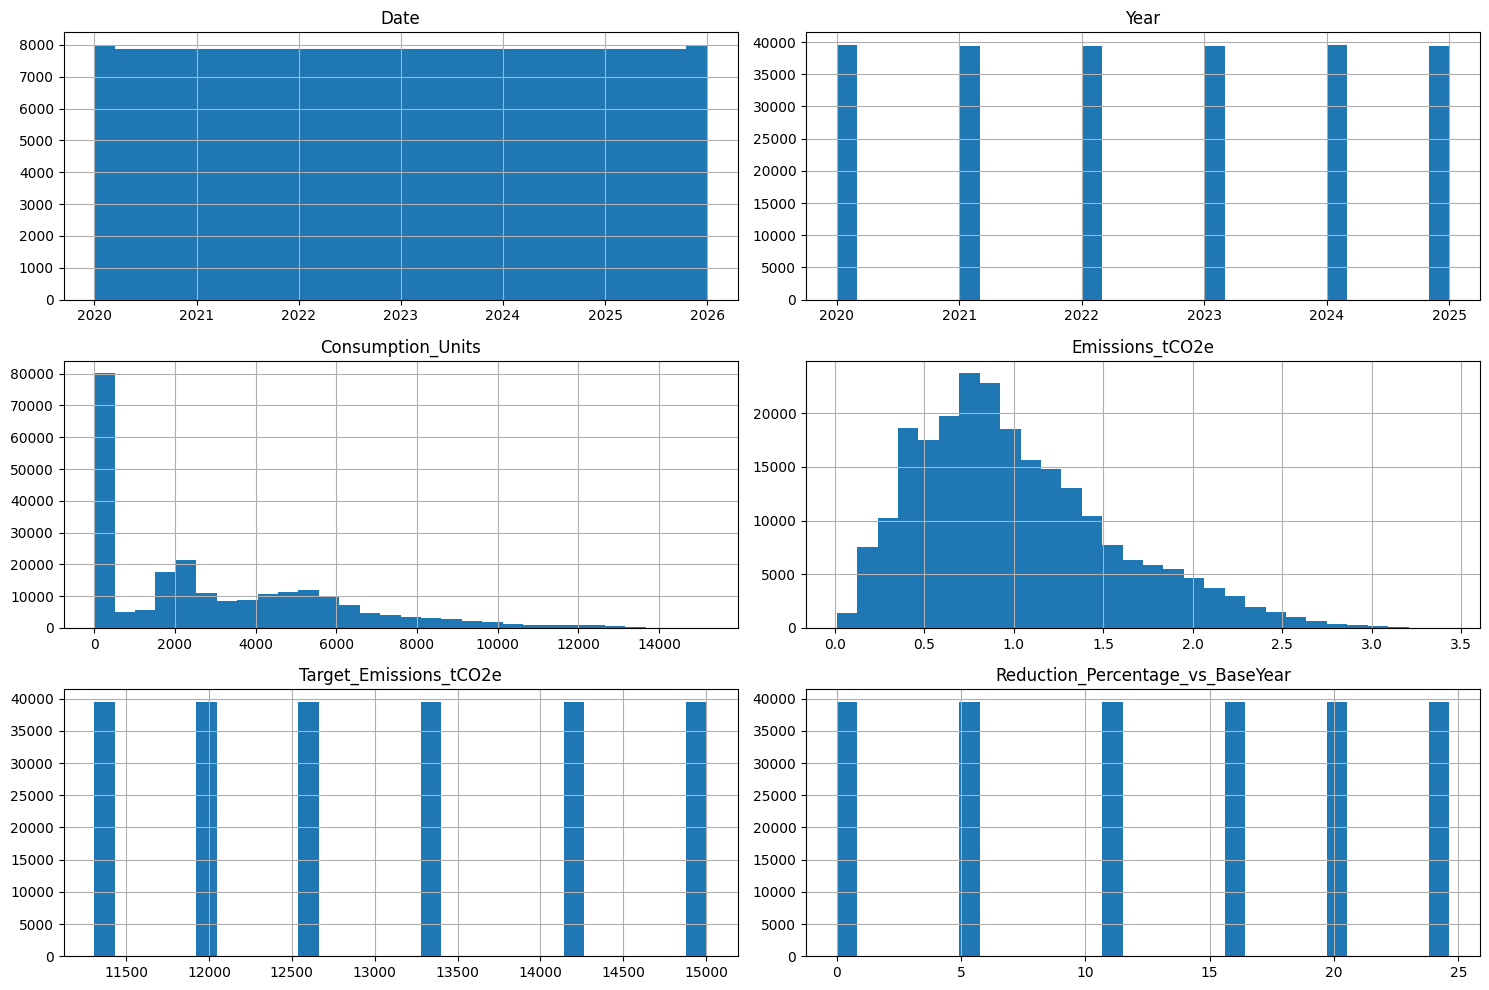

In [9]:
import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

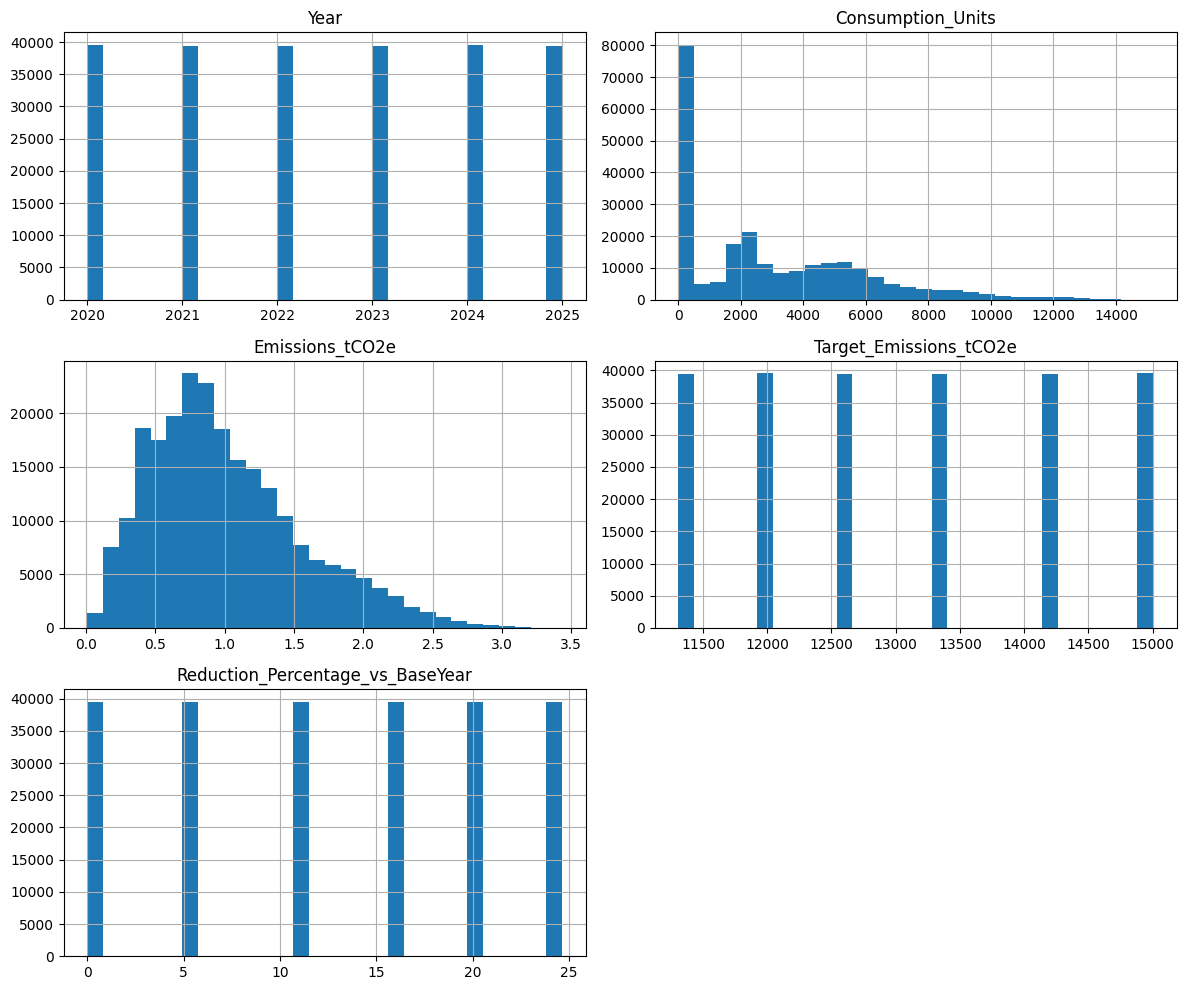

In [10]:
import matplotlib.pyplot as plt

df.select_dtypes(include='number').hist(bins=30, figsize=(12,10))
plt.tight_layout()
plt.show()

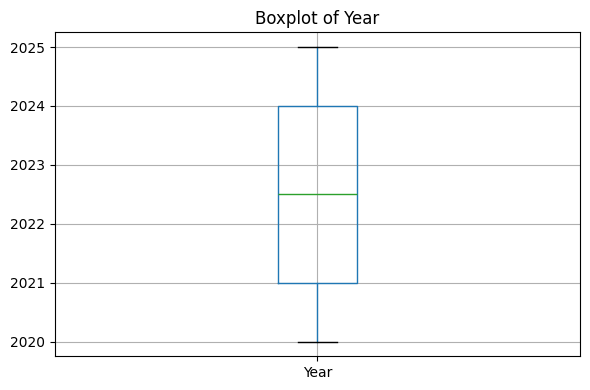

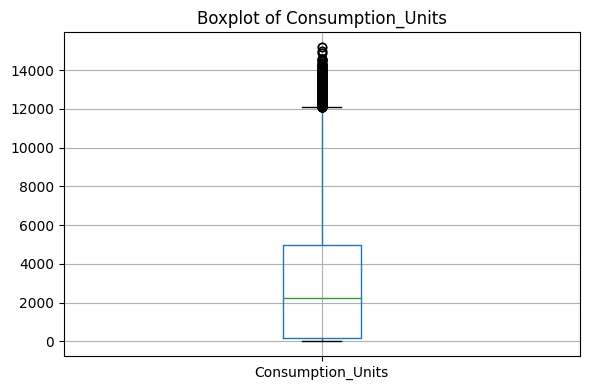

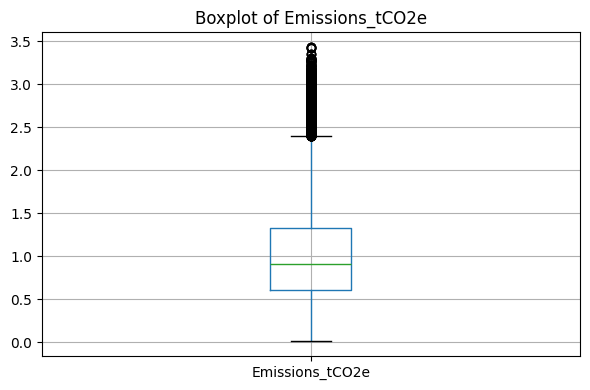

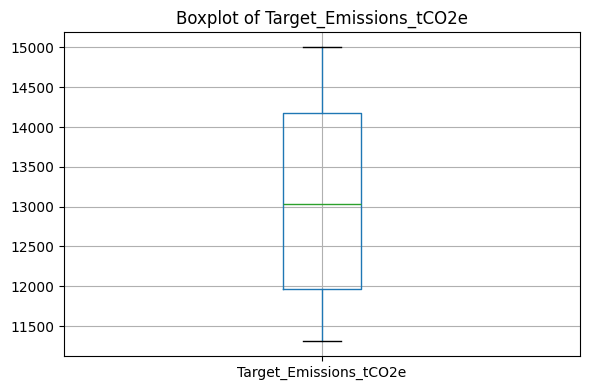

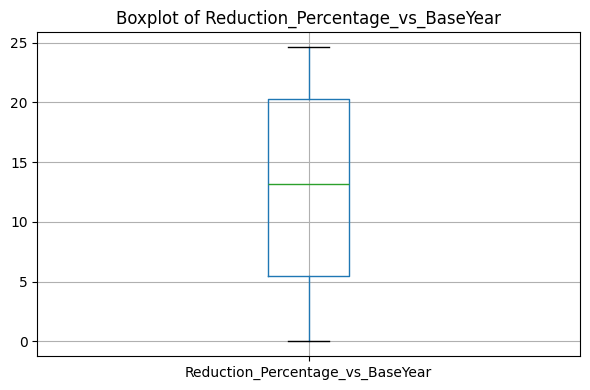

In [11]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# Select only numeric columns
numeric_df = df.select_dtypes(include='numbers')

# Calculate statistics
stats = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Std_Deviation': numeric_df.std(),
    'Skewness': numeric_df.skew(),
    'Kurtosis': numeric_df.kurtosis()
})

print(stats)

                                          Mean        Median  Std_Deviation  \
Year                               2022.499544   2022.500000       1.708185   
Consumption_Units                  2974.985016   2251.237000    2913.827113   
Emissions_tCO2e                       1.011650      0.906257       0.552706   
Target_Emissions_tCO2e            13086.800251  13030.775500    1263.214803   
Reduction_Percentage_vs_BaseYear     12.780908     13.155000       8.419583   

                                  Skewness  Kurtosis  
Year                             -0.000320 -1.269231  
Consumption_Units                 0.972808  0.424688  
Emissions_tCO2e                   0.812232  0.367291  
Target_Emissions_tCO2e            0.106095 -1.258962  
Reduction_Percentage_vs_BaseYear -0.106066 -1.258740  
